<a href="https://colab.research.google.com/github/karthickT9865/Student_performanace/blob/main/DAY_2_MINI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("ALL Libraries imported successfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

ALL Libraries imported successfully
pandas version:2.2.2
sqlite3 version:2.6.0


In [51]:
df=pd.read_csv("/content/drive/MyDrive/Student perfromance/student_performance.csv")
# Generate a bar plot of average math score by gender
gender_stats = df.groupby('gender')['math_score'].mean().reset_index()

plt.figure(figsize=(7, 5))
plt.bar(gender_stats['gender'], gender_stats['math_score'], color=['skyblue', 'lightcoral'])
plt.xlabel('Gender')
plt.ylabel('Average Math Score')
plt.title('Average Math Score by Gender')
plt.grid(axis='y', linestyle='--')
plt.show()

In [43]:
df

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023


In [7]:
conn=sqlite3.connect('student_performance.db')

In [8]:
conn

In [11]:
Cursor=conn.cursor()

df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

30

In [27]:
conn=sqlite3.connect('student_performance.db') # Re-establish connection
cursor=conn.cursor()
query="""
SELECT name,department,math_score
from students
where math_score>=90
order by math_score desc
"""
df=pd.read_sql(query,conn)
print(df)
conn.close() # Close connection after use in this cell

             name        department  math_score
0      Ananya Das  Computer Science          95
1     Tanvi Mehta  Computer Science          93
2      Arjun Nair  Computer Science          92
3  Akanksha Yadav  Computer Science          91
4  Swati Kulkarni  Computer Science          90


In [29]:
conn=sqlite3.connect('student_performance.db') # Re-establish connection

cursor=conn.cursor()
query="""
SELECT name,department,attendance_percentage
from students
where attendance_percentage>90
AND department != 'Civil'
order by attendance_percentage desc
"""
df=pd.read_sql(query,conn)
print(df)
conn.close()


             name        department  attendance_percentage
0      Ananya Das  Computer Science                     98
1     Tanvi Mehta  Computer Science                     97
2     Divya Singh  Computer Science                     96
3     Sneha Reddy        Mechanical                     95
4  Akanksha Yadav  Computer Science                     95
5  Swati Kulkarni  Computer Science                     94
6    Ritu Agarwal       Electronics                     93
7    Aarav Sharma  Computer Science                     92
8   Kavya Nambiar        Mechanical                     91
9       Amit Bose  Computer Science                     91


In [30]:
conn=sqlite3.connect('student_performance.db') # Re-establish connection

cursor=conn.cursor()
query="""
SELECT name,department,attendance_percentage
from students
where attendance_percentage>93
AND department != 'Mechanical'
order by attendance_percentage desc
"""
df=pd.read_sql(query,conn)
print(df)
conn.close()

             name        department  attendance_percentage
0      Ananya Das  Computer Science                     98
1     Tanvi Mehta  Computer Science                     97
2     Divya Singh  Computer Science                     96
3  Akanksha Yadav  Computer Science                     95
4  Swati Kulkarni  Computer Science                     94


In [34]:
conn=sqlite3.connect('student_performance.db') # Re-establish connection
queryS="""
select
  department,
  count(*) as num_student,
  round(avg(math_score),2),
  round(avg(science_score),2),
  round(avg(programming_score),2),
  round(avg(attendance_percentage),2)
  from students
  group by department
  order by math_score desc
"""
df=pd.read_sql(queryS,conn)
print(df)
conn.close()

         department  num_student  round(avg(math_score),2)  \
0  Computer Science           13                     85.62   
1             Civil            5                     63.40   
2        Mechanical            6                     71.00   
3       Electronics            6                     71.00   

   round(avg(science_score),2)  round(avg(programming_score),2)  \
0                        84.46                            89.23   
1                        66.60                            40.60   
2                        76.50                            49.33   
3                        74.17                            61.50   

   round(avg(attendance_percentage),2)  
0                                90.69  
1                                74.60  
2                                83.50  
3                                80.33  


In [37]:
conn=sqlite3.connect('student_performance.db') # Re-establish connection
queryS="""
select
  department,
  count(*) as num_student,
  round(avg(math_score),2) as avg_math_score

  from students
  group by department
  having avg(math_score)>70
  order by avg_math_score desc
"""
df=pd.read_sql(queryS,conn)
print(df)
conn.close()

         department  num_student  avg_math_score
0  Computer Science           13           85.62
1        Mechanical            6           71.00
2       Electronics            6           71.00


In [39]:
conn=sqlite3.connect('student_performance.db') # Re-establish connection
query="""
select
  gender,
  count(*) as num_students,
  round(avg(math_score),2) as avg_math_score,
  round(avg(programming_score),2) as avg_pro_score,
  round(avg(attendance_percentage),2) as avg_att_score
from students
group by gender
"""
df=pd.read_sql(query,conn)
print(df)
conn.close()

   gender  num_students  avg_math_score  avg_pro_score  avg_att_score
0  Female            15           78.47           70.2          88.53
1    Male            15           73.67           65.0          80.47


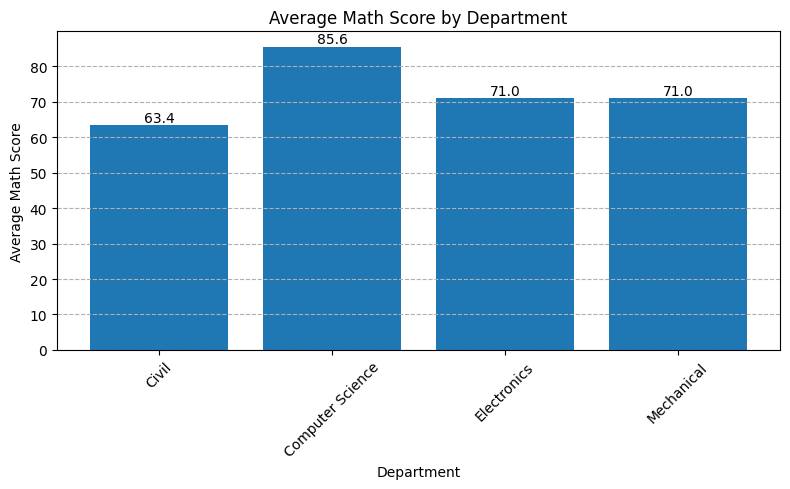

In [57]:
%matplotlib inline

import matplotlib.pyplot as plt

# Calculate average math score by department
department_math_stats = df.groupby('department')['math_score'].mean()

# Create figure
plt.figure(figsize=(8,5))

# Bar plot
plt.bar(
    department_math_stats.index,
    department_math_stats.values
)

# Labels and title
plt.xlabel('Department')
plt.ylabel('Average Math Score')
plt.title('Average Math Score by Department')

# Rotate department names
plt.xticks(rotation=45)

# Grid
plt.grid(axis='y', linestyle='--')

# Show values on bars
for i, value in enumerate(department_math_stats.values):
    plt.text(i, value + 1, f'{value:.1f}', ha='center')

plt.tight_layout()
plt.show()

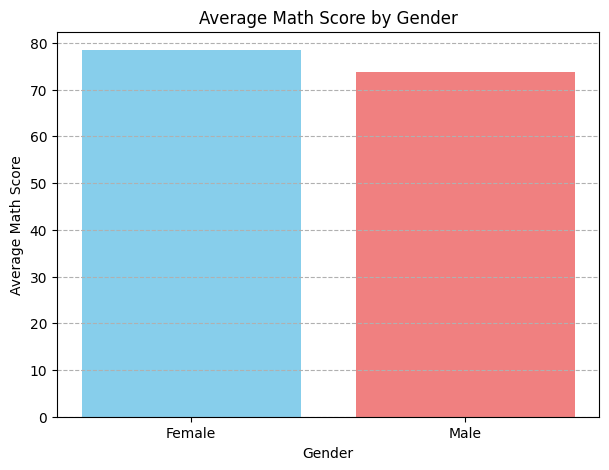

In [59]:
df=pd.read_csv("/content/drive/MyDrive/Student perfromance/student_performance.csv")
# Generate a bar plot of average math score by gender
gender_stats = df.groupby('gender')['math_score'].mean().reset_index()

plt.figure(figsize=(7, 5))
plt.bar(gender_stats['gender'], gender_stats['math_score'], color=['skyblue', 'lightcoral'])
plt.xlabel('Gender')
plt.ylabel('Average Math Score')
plt.title('Average Math Score by Gender')
plt.grid(axis='y', linestyle='--')
plt.show()

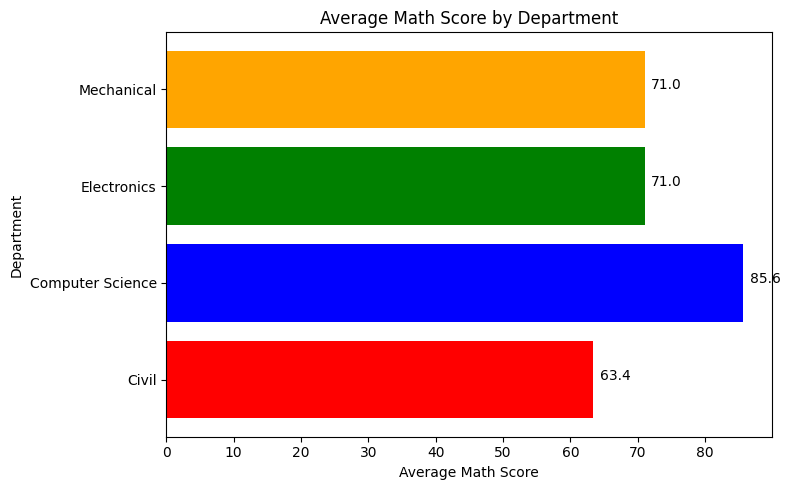

In [60]:
import matplotlib.pyplot as plt

department_math_stats = df.groupby('department')['math_score'].mean()

colors = ['red', 'blue', 'green', 'orange', 'purple', 'pink', 'brown', 'cyan']

plt.figure(figsize=(8,5))

# Horizontal bar plot
plt.barh(
    department_math_stats.index,
    department_math_stats.values,
    color=colors[:len(department_math_stats)]
)

# Swapped axis labels
plt.ylabel('Department')
plt.xlabel('Average Math Score')

plt.title('Average Math Score by Department')



for i, value in enumerate(department_math_stats.values):
    plt.text(value + 1, i, f'{value:.1f}')

plt.tight_layout()
plt.show()

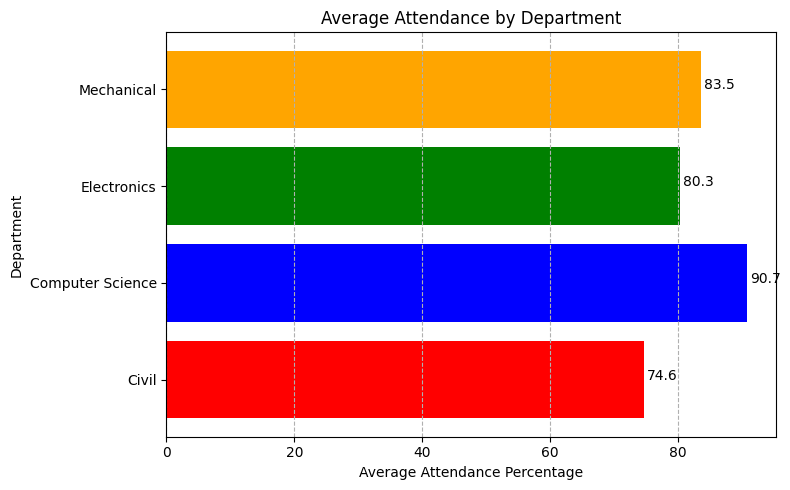

In [62]:
import matplotlib.pyplot as plt

# Calculate average attendance by department
attendance_stats = df.groupby('department')['attendance_percentage'].mean()

colors = ['red', 'blue', 'green', 'orange', 'purple', 'pink', 'brown', 'cyan']

plt.figure(figsize=(8,5))

# Horizontal bar plot
plt.barh(
    attendance_stats.index,
    attendance_stats.values,
    color=colors[:len(attendance_stats)]
)

# Labels
plt.ylabel('Department')
plt.xlabel('Average Attendance Percentage')

plt.title('Average Attendance by Department')

# Grid
plt.grid(axis='x', linestyle='--')

# Show values
for i, value in enumerate(attendance_stats.values):
    plt.text(value + 0.5, i, f'{value:.1f}')

plt.tight_layout()
plt.show()

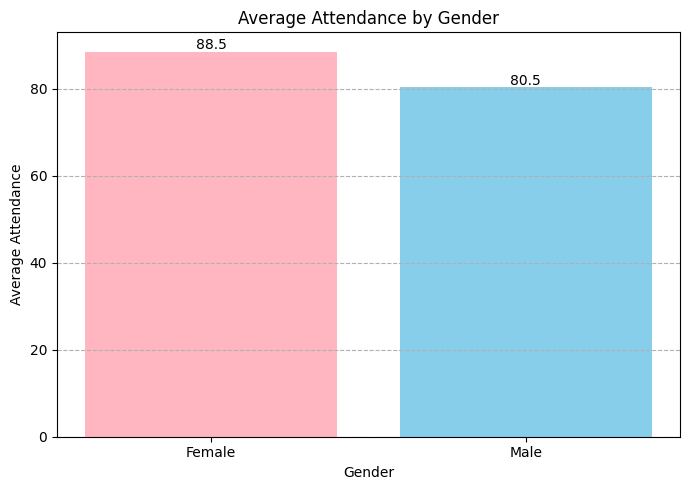

In [65]:
import matplotlib.pyplot as plt

# Calculate average attendance by gender
attendance_stats = df.groupby('gender')['attendance_percentage'].mean()

colors = ['lightpink', 'skyblue']

plt.figure(figsize=(7,5))

# Bar plot
plt.bar(
    attendance_stats.index,
    attendance_stats.values,
    color=colors
)

# Labels
plt.xlabel('Gender')
plt.ylabel('Average Attendance')

plt.title('Average Attendance by Gender')

# Grid
plt.grid(axis='y', linestyle='--')

# Show values on bars
for i, value in enumerate(attendance_stats.values):
    plt.text(i, value + 0.5, f'{value:.1f}', ha='center')

plt.tight_layout()
plt.show()

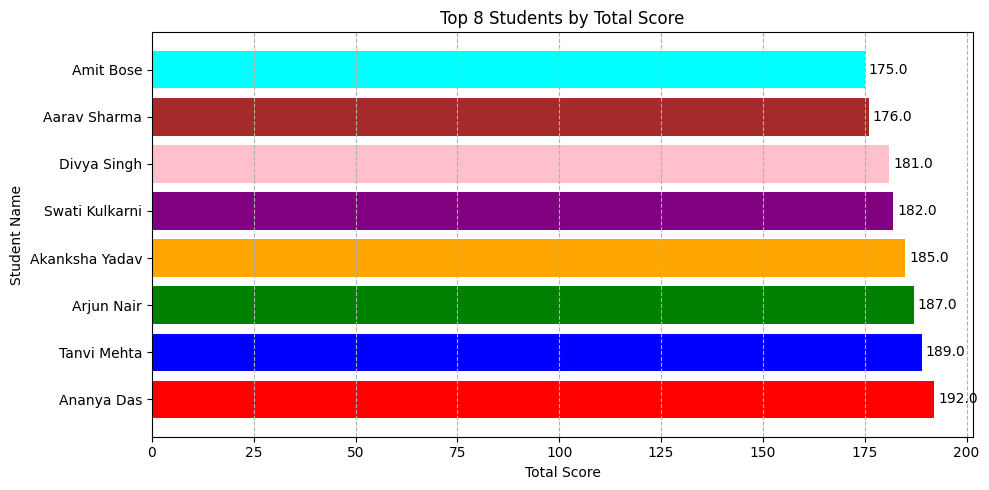

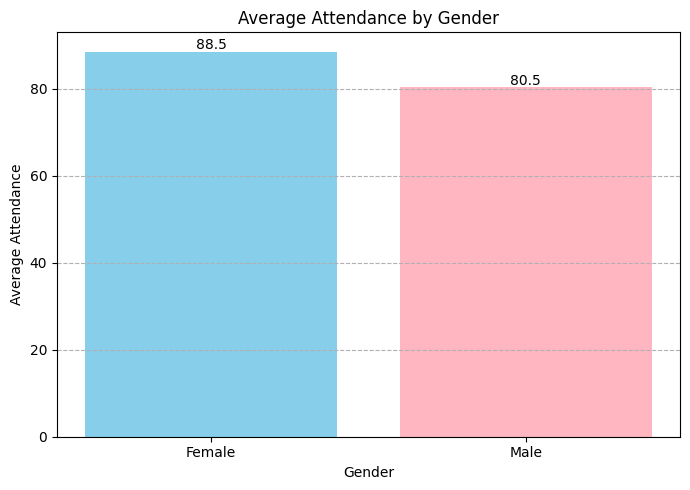

In [74]:
import matplotlib.pyplot as plt

# Create total score column
df['total_score'] = (
    df['math_score'] +
    df['programming_score']
)

# Get top 8 students
top_students = df.nlargest(8, 'total_score')

colors = ['red', 'blue', 'green', 'orange', 'purple', 'pink', 'brown', 'cyan']

# -----------------------------
# Graph 1 : Total Score
# -----------------------------
plt.figure(figsize=(10,5))

plt.barh(
    top_students['name'],
    top_students['total_score'],
    color=colors
)

plt.ylabel('Student Name')
plt.xlabel('Total Score')

plt.title('Top 8 Students by Total Score')

# Removed plt.xticks(rotation=45) as it's for vertical bars

plt.grid(axis='x', linestyle='--') # Changed to axis='x' for horizontal bars

for i, value in enumerate(top_students['total_score']):
    plt.text(value + 1, i, f'{value:.1f}', va='center') # Adjusted text position for horizontal bars

plt.tight_layout()
plt.show()


# -----------------------------
# Graph 2 : Average Attendance by Gender
# -----------------------------
attendance_stats = df.groupby('gender')['attendance_percentage'].mean()

plt.figure(figsize=(7,5))

plt.bar(
    attendance_stats.index,
    attendance_stats.values,
    color=['skyblue', 'lightpink']
)

plt.xlabel('Gender')
plt.ylabel('Average Attendance')

plt.title('Average Attendance by Gender')

plt.grid(axis='y', linestyle='--')

for i, value in enumerate(attendance_stats.values):
    plt.text(i, value + 0.5, f'{value:.1f}', ha='center')

plt.tight_layout()
plt.show()

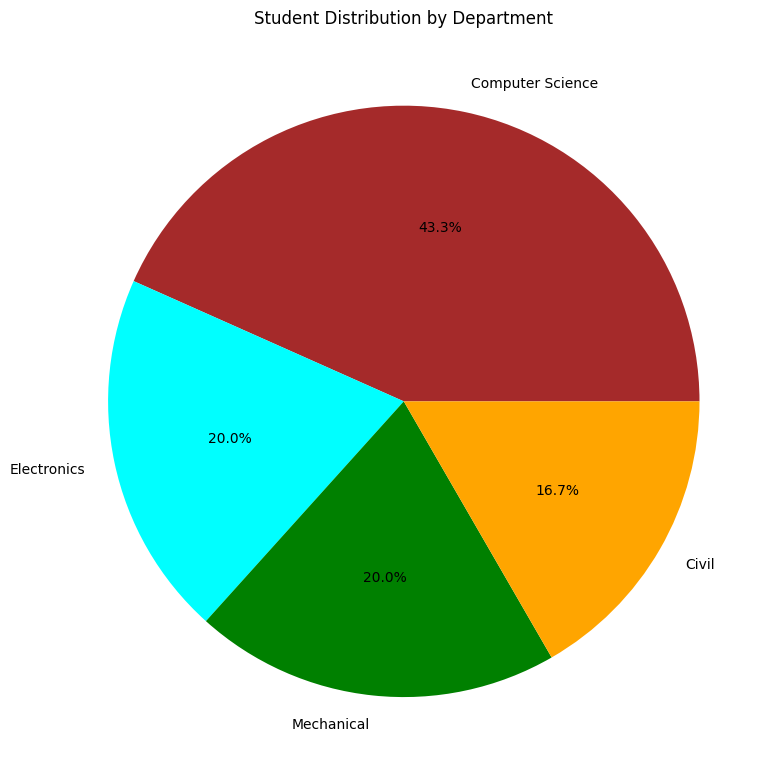

In [77]:
import matplotlib.pyplot as plt

# Count students in each department
department_counts = df['department'].value_counts()

colors = ['brown', 'cyan', 'green', 'orange', 'purple', 'pink', 'brown', 'cyan']

plt.figure(figsize=(8,8))

# Pie chart
plt.pie(
    department_counts.values,
    labels=department_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(department_counts)]
)

plt.title('Student Distribution by Department')

plt.tight_layout()
plt.show()

In [79]:
conn = sqlite3.connect('student_performance.db') # Re-establish connection
query = """
SELECT AVG(programming_score) AS average_programming_score
FROM students
WHERE gender = 'Female';
"""
df_result = pd.read_sql(query, conn)
print(df_result)
conn.close() # Close connection

   average_programming_score
0                       70.2
